# Dates and Time Series in Python

A hands-on notebook. Work through it top to bottom. Each part has short notes, runnable examples, and a few practice tasks with solutions hidden right below them.

The order goes: plain Python dates first, then formatting, then pandas time series, then the more advanced stuff (resampling, rolling windows, time zones), and finally a small project to tie it together.

**How to use this notebook**
- Run each cell with `Shift + Enter`.
- Try the practice cells yourself before opening the solution underneath.
- Change the numbers and re-run things. Breaking stuff is how you learn it.

---

## Part 0 — Setup

These two imports sit at the top of almost every data notebook. `pandas` (nicknamed `pd`) handles tables and time series. `numpy` (nicknamed `np`) handles numbers and math. The `as pd` / `as np` part just gives them short names so you type less.

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# so the random numbers come out the same every time you run this
np.random.seed(42)

print("pandas:", pd.__version__)
print("numpy :", np.__version__)
print("ready to go")

pandas: 2.3.2
numpy : 2.2.6
ready to go


---
## Part 1 — Plain Python dates (`datetime`)

Before pandas, Python already has a `datetime` object built in. It represents one specific moment: a year, month, day, and optionally hour/minute/second.

You build one by passing the parts in order: `datetime(year, month, day, hour, minute, second)`. Anything you leave off defaults to zero.

In [23]:
# January 3rd, 2011 at midnight (no time given, so it's 00:00:00)
stamp = datetime(2011, 1, 3)
print("stamp",stamp)

# with a time as well
meeting = datetime(2026, 6, 20, 14, 30)   # 20 June 2026, 2:30 PM
print("meeting:", meeting)

# right now, straight off your machine's clock
print(datetime.now())
print("Date & Time:",datetime.now().strftime("%Y-%m-%d %I:%M:%S.%f %p"))

stamp 2011-01-03 00:00:00
meeting: 2026-06-20 14:30:00
2026-06-20 13:19:26.640727
Date & Time: 2026-06-20 01:19:26.641043 PM


Once you have a `datetime`, you can pull out any piece of it. These are the attributes that exist on a date:

In [12]:
stamp = datetime(2011, 1, 4)

print("year  :", stamp.year)
print("month :", stamp.month)
print("day   :", stamp.day)
print(stamp.strftime("%A"))   # Tuesday
print(stamp.strftime("%a"))   # Tue
print("hour  :", stamp.hour)

# weekday() gives 0 = Monday ... 6 = Sunday
print("weekday number:", stamp.weekday())

year  : 2011
month : 1
day   : 4
Tuesday
Tue
hour  : 0
weekday number: 1


### Practice 1
Create a `datetime` for your own birthday this year and print which weekday it falls on (as a number, 0 = Monday).

In [24]:
# your turn
birthday = datetime(2027, 2, 18)
print(birthday.strftime("%A"))   # Tuesday
print("weekday number:", birthday.weekday())

Thursday
weekday number: 3


<details><summary>Solution</summary>

```python
bday = datetime(2026, 6, 20)   # change to your date
print(bday.weekday())
```
</details>

---
## Part 2 — Durations (`timedelta`)

A `datetime` is a *point* in time. A `timedelta` is a *length* of time — "3 days", "2 hours", "90 seconds". You use it for the gap between two dates, or to shift a date forwards or backwards.

Here's the thing that trips people up: no matter what units you pass in (weeks, hours, minutes, milliseconds...), a `timedelta` stores everything as only **three** fields — `days`, `seconds`, and `microseconds`. Everything else gets converted and folded into those.

In [26]:
delta = timedelta(
    days=50,
    seconds=27,
    microseconds=10,
    milliseconds=29000,
    minutes=5,
    hours=8,
    weeks=2
)

print(delta)                  # shown as days, H:MM:SS.microseconds
print("days        :", delta.days)
print("seconds     :", delta.seconds)
print("microseconds:", delta.microseconds)

64 days, 8:05:56.000010
days        : 64
seconds     : 29156
microseconds: 10


Walk through where those numbers come from:

- `weeks=2` becomes 14 days, plus `days=50` &rarr; **64 days**
- `hours=8` (28800s) + `minutes=5` (300s) + `seconds=27` + `milliseconds=29000` (29s) &rarr; **29156 seconds**
- `microseconds=10` stays as **10**

There is no `.weeks`, `.hours`, or `.month` on a `timedelta` — those were absorbed. Asking for them is an error:

In [30]:
# this will raise an AttributeError on purpose, so you see what it looks like
try:
    print(delta.weeks)
except AttributeError as e:
    print("AttributeError:", e)

AttributeError: 'datetime.timedelta' object has no attribute 'weeks'


The real power of `timedelta` is date arithmetic. Subtract two dates to get a duration, or add a duration to a date to get a new date.

In [31]:
start = datetime(2026, 6, 20)
end   = datetime(2026, 8, 3)

gap = end - start          # subtracting dates gives a timedelta
print("gap:", gap)
print("gap in days:", gap.days)

# add a duration to a date to move it
deadline = start + timedelta(weeks=3)
print("3 weeks after start:", deadline)

# total_seconds() flattens the whole duration into one number
print("gap in seconds:", gap.total_seconds())

gap: 44 days, 0:00:00
gap in days: 44
3 weeks after start: 2026-07-11 00:00:00
gap in seconds: 3801600.0


### Practice 2
Your project kicks off on 1 March 2026. It runs for 8 weeks and 4 days. What's the exact end date, and how many total days is that?

In [46]:
start_prjt = datetime(2026, 3, 1)
Length = timedelta(weeks=8,days=4)
enddate_prjt = start_prjt + Length
#enddate_prjt = start_prjt + timedelta(weeks=8,days=4)
print (enddate_prjt)
print("End date:", enddate_prjt)
print("in days:", length.days)
print("in seconds:", length.total_seconds())

2026-04-30 00:00:00
End date: 2026-04-30 00:00:00
in days: 60
in seconds: 5184000.0


<details><summary>Solution</summary>

```python
kickoff = datetime(2026, 3, 1)
length = timedelta(weeks=8, days=4)
print("ends:", kickoff + length)
print("total days:", length.days)
```
</details>

---
## Part 3 — Dates to text and back (`strftime` / `strptime`)

Two everyday jobs: turning a date into a nicely formatted string, and reading a string back into a real date.

`str(date)` gives you Python's default look, which always includes the time. `strftime` ("string *from* time") lets you choose the exact layout using format codes.

In [51]:
print(datetime.now())
print(datetime.now().strftime("%Y-%m-%d %I:%M:%S.%f %p"),":Date & Time")

2026-06-20 13:49:58.910903
2026-06-20 01:49:58.911431 PM :Date & Time


In [52]:
stamp = datetime.now()

print(str(stamp))                      # default: includes 00:00:00
print(stamp.strftime("%Y-%m-%d"))      # just the date
print(stamp.strftime("%d/%m/%Y"))      # day first
print(stamp.strftime("%B %d, %Y"))     # month spelled out
print(stamp.strftime("%A"))            # weekday name
print(stamp.strftime("%a"))            # weekday name

2026-06-20 13:52:52.965550
2026-06-20
20/06/2026
June 20, 2026
Saturday
Sat


The format codes worth memorising:

| Code | Meaning | Example |
|------|---------|---------|
| `%Y` | 4-digit year | 2011 |
| `%y` | 2-digit year | 11 |
| `%m` | month number | 01 |
| `%B` | month name | January |
| `%d` | day of month | 03 |
| `%A` | weekday name | Monday |
| `%H` | hour (24h) | 14 |
| `%M` | minute | 30 |
| `%S` | second | 00 |

Going the other way, `strptime` ("string *parse* time") reads a string into a `datetime`. You tell it the layout the string is in.

In [10]:
text = "03/01/2011"
parsed = datetime.strptime(text, "%d/%m/%Y")
print(parsed)
print(type(parsed))

2011-01-03 00:00:00
<class 'datetime.datetime'>


### Practice 3
You have the string `"2026-12-25 18:00"`. Parse it into a `datetime`, then print it back out as `"Friday, 25 December 2026 at 18:00"` (whatever weekday it actually is).

In [53]:
d = datetime.strptime("2026-12-25 18:00", "%Y-%m-%d %H:%M")
print(d.strftime("%A, %d %B %Y at %H:%M"))

Friday, 25 December 2026 at 18:00


<details><summary>Solution</summary>

```python
d = datetime.strptime("2026-12-25 18:00", "%Y-%m-%d %H:%M")
print(d.strftime("%A, %d %B %Y at %H:%M"))
```
</details>

---
## Part 4 — pandas parses dates: `pd.to_datetime`

Plain `datetime` is fine for one date. But real data has columns of hundreds or thousands of dates, usually sitting there as plain text. `pd.to_datetime` takes a whole list of date strings and converts them in one shot.

What comes back is a `DatetimeIndex` — pandas' container for a column of real dates.

In [54]:
datestrs = ["2011-07-06 12:00:00", "2011-08-06 00:00:00"]
idx = pd.to_datetime(datestrs)
print(idx)

DatetimeIndex(['2011-07-06 12:00:00', '2011-08-06 00:00:00'], dtype='datetime64[ns]', freq=None)


Reading that output:
- `dtype='datetime64[ns]'` means the dates are stored as numbers at nanosecond precision under the hood — that's what makes them fast to work with.
- `freq=None` means pandas didn't find a regular spacing between them.

It also copes with mixed and messy formats, and missing dates become `NaT` ("Not a Time" — the date version of a blank/`NaN`).

In [13]:
messy = ["2011-07-06", "July 6, 2011", "6/7/2011", None, ""]
print(pd.to_datetime(messy, format="mixed", dayfirst=True))

DatetimeIndex(['2011-07-06', '2011-07-06', '2011-07-06', 'NaT', 'NaT'], dtype='datetime64[ns]', freq=None)


### Practice 4
Convert this list of order dates into a `DatetimeIndex` and print it: `["2026-01-15", "2026-02-20", "2026-03-25"]`.

In [56]:
practice = ["2026-01-15", "2026-02-20", "2026-03-25"]
print(pd.to_datetime(practice, format="mixed", dayfirst=True))

orders = pd.to_datetime(["2026-01-15", "2026-02-20", "2026-03-25"])
print(orders)

DatetimeIndex(['2026-01-15', '2026-02-20', '2026-03-25'], dtype='datetime64[ns]', freq=None)
DatetimeIndex(['2026-01-15', '2026-02-20', '2026-03-25'], dtype='datetime64[ns]', freq=None)


<details><summary>Solution</summary>

```python
orders = pd.to_datetime(["2026-01-15", "2026-02-20", "2026-03-25"])
print(orders)
```
</details>

---
## Part 5 — Building a time series

A **Series** is pandas' single column: a set of labels on the left (the *index*) and values on the right. Normally the labels are 0, 1, 2...

A **time series** is just a Series where those labels are dates instead of numbers. That's the whole idea. The values are your data (sales, temperature, whatever); the date index tells you *when* each value happened.

In [15]:
dates = [datetime(2011, 1, 2), datetime(2011, 1, 5),
         datetime(2011, 1, 7), datetime(2011, 1, 8),
         datetime(2011, 1, 10), datetime(2011, 1, 12)]

ts = pd.Series(np.random.standard_normal(6), index=dates)
print(ts)

2011-01-02    0.496714
2011-01-05   -0.138264
2011-01-07    0.647689
2011-01-08    1.523030
2011-01-10   -0.234153
2011-01-12   -0.234137
dtype: float64


Read it as two columns: dates on the left (the index), random values on the right (the data).

Even though we handed it a plain Python list of `datetime` objects, pandas quietly converted them into a `DatetimeIndex`:

In [16]:
print(ts.index)
print()
print("type of the index:", type(ts.index).__name__)
print("first label      :", ts.index[0])

DatetimeIndex(['2011-01-02', '2011-01-05', '2011-01-07', '2011-01-08',
               '2011-01-10', '2011-01-12'],
              dtype='datetime64[ns]', freq=None)

type of the index: DatetimeIndex
first label      : 2011-01-02 00:00:00


### Practice 5
Make a time series of 5 daily temperatures starting 1 June 2026. Use values `[22, 24, 19, 25, 23]` and a date index you build by hand.

In [61]:
# your turn
days = [datetime(2026, 6, d) for d in range(1, 6)]
print (days[1])

2026-06-02 00:00:00


In [59]:
temps = pd.Series([22, 24, 19, 25, 23], index=days)
print(temps)

2026-06-01    22
2026-06-02    24
2026-06-03    19
2026-06-04    25
2026-06-05    23
dtype: int64


<details><summary>Solution</summary>

```python
days = [datetime(2026, 6, d) for d in range(1, 6)]
temps = pd.Series([22, 24, 19, 25, 23], index=days)
print(temps)
```
</details>

---
## Part 6 — Selecting and slicing by date

This is the payoff for having dates as the index. You can grab rows by date in ways that would be impossible with plain text labels.

In [63]:
# a longer series: 1000 days of data
long_ts = pd.Series(np.random.standard_normal(1000),
                    index=pd.date_range("2020-01-01", periods=1000))
print(long_ts.head())
print("...")
print("total points:", len(long_ts))

2020-01-01    0.496714
2020-01-02   -0.138264
2020-01-03    0.647689
2020-01-04    1.523030
2020-01-05   -0.234153
Freq: D, dtype: float64
...
total points: 1000


In [19]:
# one exact day
print(long_ts["2020-01-03"])

-0.4694743859349521


In [20]:
# a whole month — pandas understands partial dates
print(long_ts["2020-02"].head())
print("February 2020 has", len(long_ts["2020-02"]), "points")

2020-02-01   -1.959670
2020-02-02   -1.328186
2020-02-03    0.196861
2020-02-04    0.738467
2020-02-05    0.171368
Freq: D, dtype: float64
February 2020 has 29 points


In [21]:
# a whole year
print("2021 has", len(long_ts["2021"]), "points")

# a range between two dates (both ends included)
print(long_ts["2020-01-05":"2020-01-09"])

2021 has 365 points
2020-01-05   -0.463418
2020-01-06   -0.465730
2020-01-07    0.241962
2020-01-08   -1.913280
2020-01-09   -1.724918
Freq: D, dtype: float64


### Practice 6
From `long_ts`, pull out every value in March 2022 and print its average.

In [73]:
# a whole year
print(long_ts["2020-03"])
print("March has", len(long_ts["2022-03"]), "points")
print("...")
print(long_ts["2020-03"].mean())
print("...")
print(long_ts["2020-03"].sum()/len(long_ts["2022-03"]))

2020-03-01   -0.479174
2020-03-02   -0.185659
2020-03-03   -1.106335
2020-03-04   -1.196207
2020-03-05    0.812526
2020-03-06    1.356240
2020-03-07   -0.072010
2020-03-08    1.003533
2020-03-09    0.361636
2020-03-10   -0.645120
2020-03-11    0.361396
2020-03-12    1.538037
2020-03-13   -0.035826
2020-03-14    1.564644
2020-03-15   -2.619745
2020-03-16    0.821903
2020-03-17    0.087047
2020-03-18   -0.299007
2020-03-19    0.091761
2020-03-20   -1.987569
2020-03-21   -0.219672
2020-03-22    0.357113
2020-03-23    1.477894
2020-03-24   -0.518270
2020-03-25   -0.808494
2020-03-26   -0.501757
2020-03-27    0.915402
2020-03-28    0.328751
2020-03-29   -0.529760
2020-03-30    0.513267
2020-03-31    0.097078
Freq: D, dtype: float64
March has 31 points
...
0.015600668500475515
...
0.015600668500475515


<details><summary>Solution</summary>

```python
print(long_ts["2022-03"].mean())
```
</details>

---
## Part 7 — Generating dates with `pd.date_range`

You rarely type dates by hand. `pd.date_range` builds an evenly spaced `DatetimeIndex` for you. You give it a start plus either an end or a number of periods, and a frequency.

In [23]:
# every day for two weeks
print(pd.date_range("2026-01-01", periods=14, freq="D"))

DatetimeIndex(['2026-01-01', '2026-01-02', '2026-01-03', '2026-01-04',
               '2026-01-05', '2026-01-06', '2026-01-07', '2026-01-08',
               '2026-01-09', '2026-01-10', '2026-01-11', '2026-01-12',
               '2026-01-13', '2026-01-14'],
              dtype='datetime64[ns]', freq='D')


In [24]:
# common frequencies
print("Month ends  :", list(pd.date_range("2026-01-01", periods=4, freq="ME").strftime("%Y-%m-%d")))
print("Weekly (Sun):", list(pd.date_range("2026-01-01", periods=4, freq="W").strftime("%Y-%m-%d")))
print("Hourly      :", list(pd.date_range("2026-01-01", periods=4, freq="h").strftime("%Y-%m-%d %H:%M")))
print("Business day:", list(pd.date_range("2026-01-01", periods=5, freq="B").strftime("%a %Y-%m-%d")))

Month ends  : ['2026-01-31', '2026-02-28', '2026-03-31', '2026-04-30']
Weekly (Sun): ['2026-01-04', '2026-01-11', '2026-01-18', '2026-01-25']
Hourly      : ['2026-01-01 00:00', '2026-01-01 01:00', '2026-01-01 02:00', '2026-01-01 03:00']
Business day: ['Thu 2026-01-01', 'Fri 2026-01-02', 'Mon 2026-01-05', 'Tue 2026-01-06', 'Wed 2026-01-07']


Frequency cheat sheet: `D` day, `B` business day, `W` week, `ME` month-end, `MS` month-start, `h` hour, `min` minute, `QE` quarter-end, `YE` year-end.

### Practice 7
Build a date index of the first day of every month in 2026 (12 dates).

In [77]:
print("First day  :", list(pd.date_range("2026-01-01", periods=12, freq="MS").strftime("%a")))
print(pd.date_range("2026-01-01", periods=12, freq="MS"))

First day  : ['Thu', 'Sun', 'Sun', 'Wed', 'Fri', 'Mon', 'Wed', 'Sat', 'Tue', 'Thu', 'Sun', 'Tue']
DatetimeIndex(['2026-01-01', '2026-02-01', '2026-03-01', '2026-04-01',
               '2026-05-01', '2026-06-01', '2026-07-01', '2026-08-01',
               '2026-09-01', '2026-10-01', '2026-11-01', '2026-12-01'],
              dtype='datetime64[ns]', freq='MS')


<details><summary>Solution</summary>

```python
print(pd.date_range("2026-01-01", periods=12, freq="MS"))
```
</details>

---
## Part 8 — Resampling (changing the time frequency)

Resampling means rolling data up to a coarser frequency (daily &rarr; monthly) or down to a finer one. It's like `groupby`, but the groups are time buckets. You pick the new frequency and then an aggregation (`sum`, `mean`, etc.).

In [94]:
# daily data for one year
daily = pd.Series(np.random.standard_normal(365),
                  index=pd.date_range("2025-01-01", periods=365, freq="D"))

# roll up to monthly averages
monthly = daily.resample("ME").mean()
print(monthly)

2025-01-31    0.153193
2025-02-28   -0.008700
2025-03-31    0.207379
2025-04-30   -0.043098
2025-05-31   -0.133911
2025-06-30    0.374805
2025-07-31   -0.136265
2025-08-31    0.085230
2025-09-30    0.375477
2025-10-31    0.068435
2025-11-30   -0.308488
2025-12-31   -0.021269
Freq: ME, dtype: float64


A quick picture makes the difference obvious — the noisy daily line versus the smooth monthly average.

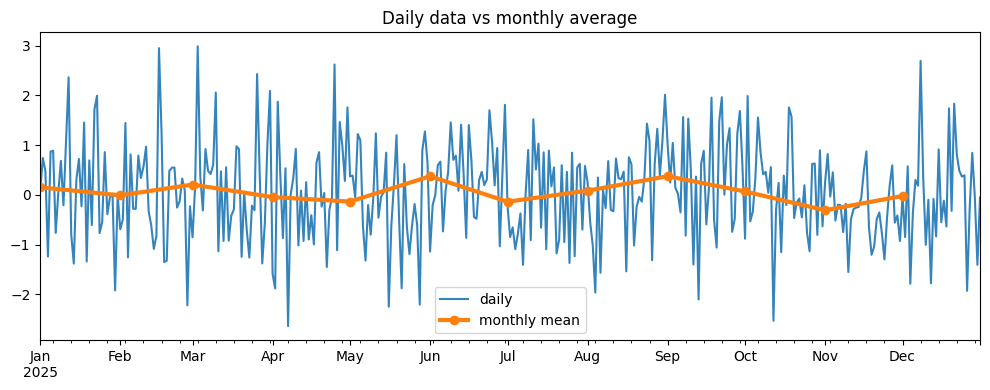

In [95]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
daily.plot(ax=ax, alpha=0.9, label="daily")
monthly.plot(ax=ax, marker="o", linewidth=3, label="monthly mean")
ax.set_title("Daily data vs monthly average")
ax.legend()
plt.tight_layout()
plt.show()

### Practice 8
Take `daily` and resample it to **weekly totals** (sum, not mean). Print the first 5 weeks.

In [97]:
# your turn
daily2 = daily.resample("W").sum()
print(daily2.head())

2025-01-05    0.932380
2025-01-12    4.072808
2025-01-19   -1.257861
2025-01-26    3.342325
2025-02-02   -3.523515
Freq: W-SUN, dtype: float64


<details><summary>Solution</summary>

```python
print(daily.resample("W").sum().head())
```
</details>

---
## Part 9 — Shifting and rolling windows (moderate)

Two tools you'll use constantly with time series.

**`shift`** moves the values up or down relative to the dates. Great for "compared to yesterday" calculations.

**`rolling`** computes over a sliding window — a moving average smooths out noise so the trend shows.

In [114]:
s = pd.Series([10, 12, 13, 12, 16, 18, 20],
              index=pd.date_range("2026-01-01", periods=7))

frame = pd.DataFrame({"value": s})
frame["yesterday"] = s.shift(1)               # value from the day before
frame["change"] = s - s.shift(1)              # day-over-day difference
frame["pct_change"] = s.pct_change().round(3) # same as a percentage
print(frame)

            value  yesterday  change  pct_change
2026-01-01     10        NaN     NaN         NaN
2026-01-02     12       10.0     2.0       0.200
2026-01-03     13       12.0     1.0       0.083
2026-01-04     12       13.0    -1.0      -0.077
2026-01-05     16       12.0     4.0       0.333
2026-01-06     18       16.0     2.0       0.125
2026-01-07     20       18.0     2.0       0.111


In [115]:
# a 3-day moving average smooths the line
frame["roll_mean_3"] = s.rolling(window=3).mean()
print(frame[["value", "roll_mean_3"]])
(10+12+13)/3

            value  roll_mean_3
2026-01-01     10          NaN
2026-01-02     12          NaN
2026-01-03     13    11.666667
2026-01-04     12    12.333333
2026-01-05     16    13.666667
2026-01-06     18    15.333333
2026-01-07     20    18.000000


11.666666666666666

The first couple of rolling values are `NaN` because there aren't 3 days yet to average. That's expected.

### Practice 9
Using `s` above, add a column for the **2-day rolling maximum**.

In [116]:
# your turn
# a 2-day moving average smooths the line
#frame["roll_mean_2"] = s.rolling(window=2).mean()
frame["roll_mean_2x"] = s.rolling(window=2).max()
print(frame)

            value  yesterday  change  pct_change  roll_mean_3  roll_mean_2x
2026-01-01     10        NaN     NaN         NaN          NaN           NaN
2026-01-02     12       10.0     2.0       0.200          NaN          12.0
2026-01-03     13       12.0     1.0       0.083    11.666667          13.0
2026-01-04     12       13.0    -1.0      -0.077    12.333333          13.0
2026-01-05     16       12.0     4.0       0.333    13.666667          16.0
2026-01-06     18       16.0     2.0       0.125    15.333333          18.0
2026-01-07     20       18.0     2.0       0.111    18.000000          20.0


<details><summary>Solution</summary>

```python
print(s.rolling(window=2).max())
```
</details>

---
## Part 10 — Time zones (advanced)

By default pandas timestamps are "naive" — they carry no time zone. You can attach one with `tz_localize`, then convert to another zone with `tz_convert`. The underlying moment stays the same; only the wall-clock label changes.

In [32]:
naive = pd.date_range("2026-06-20 09:00", periods=3, freq="h")
print("naive (no zone):")
print(naive)

# say these times are in UTC
utc = naive.tz_localize("UTC")
print("\nlocalised to UTC:")
print(utc)

# now show the same instants in Beirut local time
beirut = utc.tz_convert("Asia/Beirut")
print("\nconverted to Beirut:")
print(beirut)

naive (no zone):
DatetimeIndex(['2026-06-20 09:00:00', '2026-06-20 10:00:00',
               '2026-06-20 11:00:00'],
              dtype='datetime64[ns]', freq='h')

localised to UTC:
DatetimeIndex(['2026-06-20 09:00:00+00:00', '2026-06-20 10:00:00+00:00',
               '2026-06-20 11:00:00+00:00'],
              dtype='datetime64[ns, UTC]', freq='h')

converted to Beirut:
DatetimeIndex(['2026-06-20 12:00:00+03:00', '2026-06-20 13:00:00+03:00',
               '2026-06-20 14:00:00+03:00'],
              dtype='datetime64[ns, Asia/Beirut]', freq='h')


Notice the hours shift by the offset but the moment in time is identical — 09:00 UTC is the same instant as 12:00 in Beirut.

### Practice 10
Take `09:00 on 1 July 2026` in `"America/New_York"` and find out what time that is in `"Asia/Dubai"`.

In [141]:
# your turn
ny = pd.Timestamp("2026-07-01 09:00", tz="America/New_York")
print(ny,"America/New_York")
print(ny.tz_convert("UTC"),"UTC")
print(ny.tz_convert("Asia/Dubai"),"Asia/Dubai")

2026-07-01 09:00:00-04:00 America/New_York
2026-07-01 13:00:00+00:00 UTC
2026-07-01 17:00:00+04:00 Asia/Dubai


<details><summary>Solution</summary>

```python
ny = pd.Timestamp("2026-07-01 09:00", tz="America/New_York")
print(ny.tz_convert("Asia/Dubai"))
```
</details>

---
## Part 11 — Mini project: a year of site progress

Time to put it together. Imagine daily "percent complete reported" readings for a construction site across 2025. We'll build the series, clean it, and answer a few questions — the kind of thing you'd actually do with real data.

In [144]:
# fake but realistic: steady progress plus daily noise
np.random.seed(7)
idx = pd.date_range("2025-01-01", periods=365, freq="D")
trend = np.linspace(0, 100, 365)               # 0% to 100% over the year
noise = np.random.standard_normal(365) * 2
progress = pd.Series((trend + noise).clip(0, 100), index=idx)

print(progress.head())
print("...")
print(progress.tail())

2025-01-01    3.381051
2025-01-02    0.000000
2025-01-03    0.615091
2025-01-04    1.639208
2025-01-05    0.000000
Freq: D, dtype: float64
...
2025-12-27    100.000000
2025-12-28    100.000000
2025-12-29     98.478195
2025-12-30    100.000000
2025-12-31     98.690416
Freq: D, dtype: float64


**Question 1 — what was average reported progress each month?**

In [35]:
monthly_avg = progress.resample("ME").mean().round(1)
print(monthly_avg)

2025-01-31     4.0
2025-02-28    12.2
2025-03-31    20.5
2025-04-30    29.1
2025-05-31    36.4
2025-06-30    45.6
2025-07-31    53.6
2025-08-31    62.5
2025-09-30    70.9
2025-10-31    78.9
2025-11-30    87.3
2025-12-31    95.5
Freq: ME, dtype: float64


**Question 2 — which single day had the biggest jump from the day before?**

In [36]:
jumps = progress.diff()
biggest = jumps.idxmax()
print("biggest jump on:", biggest.strftime("%A %d %B %Y"))
print("jump size:", round(jumps.max(), 2), "percentage points")

biggest jump on: Tuesday 15 July 2025
jump size: 8.51 percentage points


**Question 3 — smooth the noise with a 7-day moving average and plot it.**

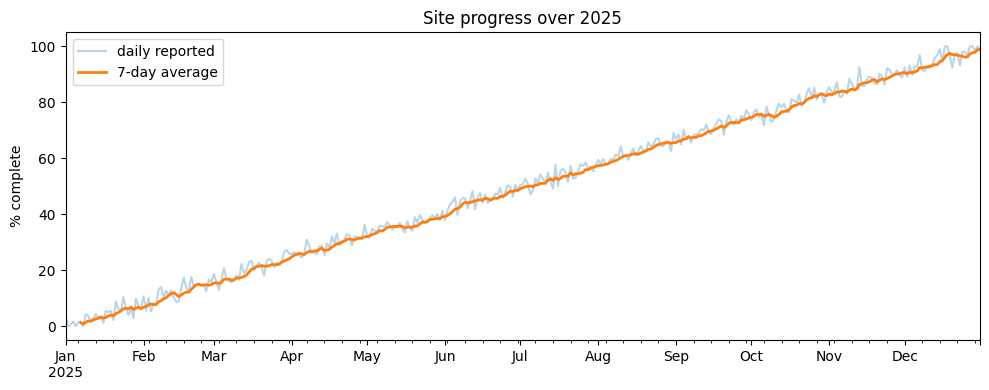

In [37]:
smooth = progress.rolling(7).mean()

fig, ax = plt.subplots(figsize=(10, 4))
progress.plot(ax=ax, alpha=0.3, label="daily reported")
smooth.plot(ax=ax, linewidth=2, label="7-day average")
ax.set_title("Site progress over 2025")
ax.set_ylabel("% complete")
ax.legend()
plt.tight_layout()
plt.show()

### Your challenge
Answer these on your own, then check against the solution:

1. What was the average progress in Q2 (April–June)?
2. How many days reported above 50% complete?
3. Resample to month-*start* (`MS`) instead of month-end and print the result.

In [158]:
# your turn
#1. What was the average progress in Q2 (April–June)?
print(progress.resample("QE").mean().round(1))
print("Q2 average:", progress.resample("QE").mean().round(1).iloc[1])
# Answer 1
print("Q2 average:", round(progress["2025-04":"2025-06"].mean(), 1))



#2. How many days reported above 50% complete?
print("days above 50%:", (progress > 50).sum())


#Resample to month-start (MS) instead of month-end and print the result.

2025-03-31    12.2
2025-06-30    37.0
2025-09-30    62.3
2025-12-31    87.2
Freq: QE-DEC, dtype: float64
Q2 average: 37.0
Q2 average: 37.0
days above 50%: 183


In [157]:
#print(progress)
print("days above 50%:", (progress > 50).sum())


days above 50%: 183


In [161]:
print(progress.resample("MS").mean().round(1))


2025-01-01     4.0
2025-02-01    12.2
2025-03-01    20.5
2025-04-01    29.1
2025-05-01    36.4
2025-06-01    45.6
2025-07-01    53.6
2025-08-01    62.5
2025-09-01    70.9
2025-10-01    78.9
2025-11-01    87.3
2025-12-01    95.5
Freq: MS, dtype: float64


<details><summary>Solution</summary>

```python
# 1
print("Q2 average:", round(progress["2025-04":"2025-06"].mean(), 1))

# 2
print("days above 50%:", (progress > 50).sum())

# 3
print(progress.resample("MS").mean().round(1))
```
</details>

---
## Recap

What you now have under your belt:

- `datetime` is one point in time; `timedelta` is a length of time (stored only as days, seconds, microseconds).
- `strftime` formats a date into text; `strptime` reads text back into a date.
- `pd.to_datetime` converts columns of date strings into a `DatetimeIndex`.
- A **time series** is just a Series whose index is dates — which unlocks slicing by `"2021"`, `"2020-02"`, or a date range.
- `pd.date_range` generates date indexes; `resample` changes their frequency.
- `shift`, `diff`, `pct_change`, and `rolling` cover most day-to-day analysis.
- `tz_localize` / `tz_convert` handle time zones.

Keep changing the inputs and re-running. That's the fastest way for this to stick.